# Lecture 5 — A/B Testing with Python

This notebook demonstrates how to conduct a basic A/B test using Python.
We first perform the analysis manually using `scipy.stats`, and then
repeat it using the `tea-tasting` library, a purpose-built package for
A/B test analysis.

We use a dataset from the mobile puzzle (match-3) game *Cookie Cats*, where the
developers ran an A/B test to decide whether a forced gate (a point where
players must wait or make a purchase) should be placed at level 30 or
level 40. The dataset contains approximately 90,000 players who were
randomly assigned to one of two groups:

| Column | Description |
|---|---|
| `userid` | Unique player identifier |
| `version` | Group assignment: `gate_30` (control) or `gate_40` (treatment) |
| `sum_gamerounds` | Total game rounds played in the first 14 days |
| `retention_1` | Did the player return the day after installing? |
| `retention_7` | Did the player return 7 days after installing? |

Data source: [Kaggle — Cookie Cats A/B Testing](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)

**Credits:**

Created by Sippo Rossi for the course Python Programming for Business Intelligence at Hanken.

---

## 1. Loading and exploring the data

As taught during the previous week, the best practice is to always conduct EDA when starting to work with a new dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.shape

(90189, 5)

In [4]:
df.dtypes

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

In [5]:
# Check group sizes
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

The groups are roughly equal in size, which is expected from proper random assignment.

## 2. Exploratory data analysis

In [6]:
# Means for the three variables, by group
df.groupby('version')[['sum_gamerounds', 'retention_1', 'retention_7']].mean()

,sum_gamerounds,retention_1,retention_7
version,,,
gate_30,52.456264,0.448188,0.190201
gate_40,51.298776,0.442283,0.182000


At a glance, the retention rates appear slightly higher for the `gate_30` group.
But are these differences statistically significant? That is what the A/B test will determine.

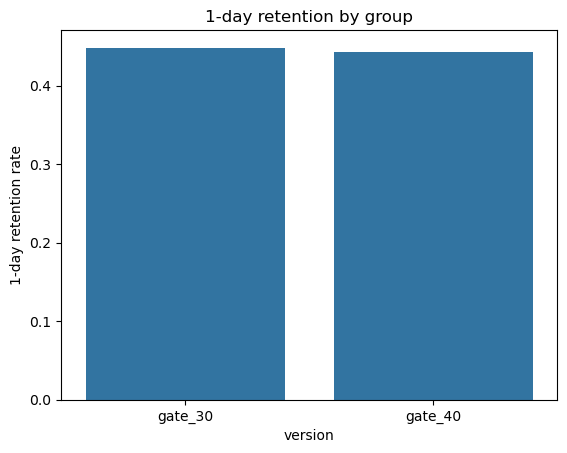

In [7]:
# Visualize 1-day retention by group
retention_1_by_group = df.groupby('version')['retention_1'].mean()

sns.barplot(x=retention_1_by_group.index, y=retention_1_by_group.values)
plt.ylabel('1-day retention rate')
plt.title('1-day retention by group');

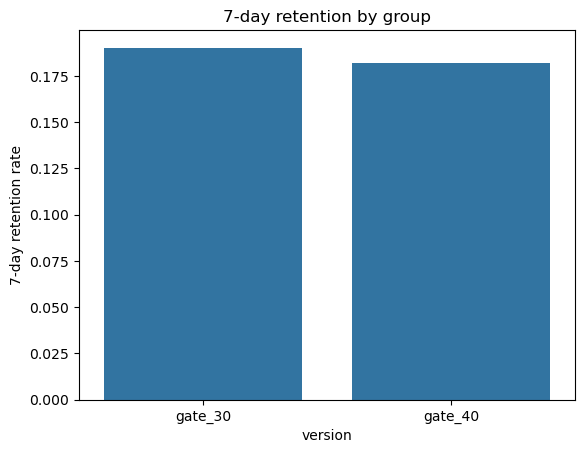

In [8]:
# Visualize 7-day retention by group
retention_7_by_group = df.groupby('version')['retention_7'].mean()

sns.barplot(x=retention_7_by_group.index, y=retention_7_by_group.values)
plt.ylabel('7-day retention rate')
plt.title('7-day retention by group');

## 3. A/B testing with `scipy.stats`

We want to test whether the difference in retention rates between the two groups
is statistically significant. Since retention is a binary outcome (True/False),
we can use a **two-proportion z-test** or equivalently a **chi-squared test**.

The hypotheses are:

**H0:** There is no difference in retention between `gate_30` and `gate_40`.

**H1:** There is a difference in retention between `gate_30` and `gate_40`.

We use a significance level of α = 0.05.

### 3.1 Testing 1-day retention

In [9]:
from scipy import stats

In [10]:
# Split the data into two groups
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

In [11]:
# For a two-proportion z-test, we need the number of successes and the sample sizes
n_30 = len(gate_30)
n_40 = len(gate_40)

# Number of players who returned on day 1
successes_30 = gate_30['retention_1'].sum()
successes_40 = gate_40['retention_1'].sum()

print(f'gate_30: {successes_30}/{n_30} = {successes_30/n_30:.4f}')
print(f'gate_40: {successes_40}/{n_40} = {successes_40/n_40:.4f}')

gate_30: 20034/44700 = 0.4482
gate_40: 20119/45489 = 0.4423


We can use `scipy.stats.chi2_contingency` to perform a chi-squared test on
the 2x2 contingency table. For binary outcomes with two groups, the chi-squared
test is equivalent to the two-proportion z-test.

In [12]:
# Build a 2x2 contingency table
#                  Returned    Did not return
# gate_30          successes   failures
# gate_40          successes   failures

contingency_table_1 = pd.crosstab(df['version'], df['retention_1'])
print(contingency_table_1)

retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119


In [13]:
# Run the chi-squared test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table_1)

print(f'Chi-squared statistic: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Degrees of freedom: {dof}')

Chi-squared statistic: 3.1591
p-value: 0.0755
Degrees of freedom: 1


In [14]:
alpha = 0.05

if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}): reject H0')
    print('The difference in 1-day retention IS statistically significant.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}): fail to reject H0')
    print('The difference in 1-day retention is NOT statistically significant.')

p-value (0.0755) >= alpha (0.05): fail to reject H0
The difference in 1-day retention is NOT statistically significant.


### 3.2 Testing 7-day retention

In [15]:
# Same approach for 7-day retention
contingency_table_7 = pd.crosstab(df['version'], df['retention_7'])
print(contingency_table_7)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table_7)

print(f'\nChi-squared statistic: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')

retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279

Chi-squared statistic: 9.9591
p-value: 0.0016


In [16]:
if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}): reject H0')
    print('The difference in 7-day retention IS statistically significant.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}): fail to reject H0')
    print('The difference in 7-day retention is NOT statistically significant.')

p-value (0.0016) < alpha (0.05): reject H0
The difference in 7-day retention IS statistically significant.


### 3.3 Testing game rounds played

For a continuous variable like `sum_gamerounds`, we can use a **t-test** to
compare the means of the two groups.

In [17]:
# Independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    gate_30['sum_gamerounds'],
    gate_40['sum_gamerounds'],
)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

t-statistic: 0.8910
p-value: 0.3729


In [18]:
if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}): reject H0')
    print('The difference in game rounds IS statistically significant.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}): fail to reject H0')
    print('The difference in game rounds is NOT statistically significant.')

p-value (0.3729) >= alpha (0.05): fail to reject H0
The difference in game rounds is NOT statistically significant.


### 3.4 Summary of results

Using SciPy, we found that:

| Metric | Significant at α = 0.05? |
|---|---|
| 1-day retention | No |
| 7-day retention | Yes |
| Game rounds played | No |

The 7-day retention rate is significantly lower when the gate is at level 40
compared to level 30. This could suggest that moving the gate later in the game
negatively affects long-term player retention.

## 4. A/B testing with the `tea-tasting` library

[tea-tasting](https://tea-tasting.e10v.me/) is a Python package designed specifically for the statistical analysis of A/B tests. It provides a high-level API that handles common tasks such as running the appropriate statistical tests, computing confidence intervals, and formatting results and even defining custom metrics.

The package name is a reference to the *Lady Tasting Tea* experiment by Ronald Fisher, which is considered the origin of null hypothesis significance testing.

In [1]:
# !pip install tea-tasting

In [20]:
import tea_tasting as tt

tea-tasting expects data where each row is one randomization unit (in our case, a
player) and the variant column indicates group assignment. Our data already has this
structure. We need to convert the boolean retention columns to integers (0/1) so
that tea-tasting can compute means.

In [21]:
# Prepare data for tea-tasting
df_tt = df.copy()   # Making a copy so we don't change the original dataframe
df_tt['retention_1'] = df_tt['retention_1'].astype(int)
df_tt['retention_7'] = df_tt['retention_7'].astype(int)

We define an experiment by specifying the metrics we want to analyze.
The `variant` parameter tells tea-tasting which column contains the group labels.

In [22]:
# Define the experiment with the metrics of interest
experiment = tt.Experiment(
    retention_1_day=tt.Mean('retention_1'),
    retention_7_day=tt.Mean('retention_7'),
    avg_game_rounds=tt.Mean('sum_gamerounds'),
    variant='version',
)

In [23]:
# Run the analysis, specifying gate_30 as the control group
result = experiment.analyze(df_tt, control='gate_30')
print(result)

metric          control treatment rel_effect_size rel_effect_size_ci  pvalue
retention_1_day   0.448     0.442           -1.3%     [-2.7%, 0.13%]  0.0744
retention_7_day   0.190     0.182           -4.3%     [-6.9%, -1.7%] 0.00156
avg_game_rounds    52.5      51.3           -2.2%      [-6.9%, 2.7%]   0.376


The output shows, for each metric, the control and treatment means, the relative effect size, confidence intervals, and p-values. This single
function call replaces the multiple manual steps we performed with scipy.

In [24]:
# The result can also be converted to a pandas DataFrame
result.to_pandas()

,metric,control,treatment,effect_size,effect_size_ci_lower,effect_size_ci_upper,rel_effect_size,rel_effect_size_ci_lower,rel_effect_size_ci_upper,pvalue,statistic
0,retention_1_day,0.448188,0.442283,-0.005905,-0.012393,0.000582,-0.013176,-0.027450,0.001308,0.074414,-1.784077
1,retention_7_day,0.190201,0.182000,-0.008201,-0.013282,-0.003121,-0.043119,-0.068892,-0.016633,0.001557,-3.164029
2,avg_game_rounds,52.456264,51.298776,-1.157488,-3.719705,1.404728,-0.022066,-0.068827,0.027044,0.375924,-0.885437


### Why the p-values differ between SciPy and tea-tasting

If you are sharp-eyed you might have noticed something different in the results. While the ultimate outcome is the same, there are very small differences in the p-values. For example, as the p-value for retention after 1 day with SciPy we got 0.0755 while with tea-tasting we got 0.074.

Why?

The SciPy version uses `chi2_contingency`, which performs a **chi-squared test** on the contingency table. The tea-tasting version uses `tt.Mean`, which performs a **t-test** (specifically, Welch's t-test by default) on the binary 0/1 values, treating retention as a continuous variable whose mean equals the proportion.

These are different tests. The chi-squared test for a 2x2 table is equivalent to the pooled two-proportion z-test (which assumes a common variance under H0). The t-test does not pool the variance estimates; it estimates the variance separately in each group. This is why the p-values are close but not identical.

Additionally, `scipy.stats.chi2_contingency` applies Yates' continuity correction by default (the `correction=True` parameter), which makes the chi-squared test slightly more conservative. You could set `correction=False` to disable it, and the p-value would shift closer to (but still not exactly match) the t-test result. 

Similarly, `scipy.stats.ttest_ind` performs Student's t-test by default (assuming equal variances), while in tea-tasting `tt.Mean` performs Welch's t-test by default.

While these approaches are methodologically correct, this example highlights how tool choice may actually lead to influencing methodological choices, and highlights importance of paying attention to details.

The code below runs the same chi-squared test for retention and for game rounds Welch's t-test with both libraries.

In [25]:
experiment = tt.Experiment(
    retention_1_day=tt.Proportion('retention_1'),
    retention_7_day=tt.Proportion('retention_7'),
    avg_game_rounds=tt.Mean('sum_gamerounds'),
    variant='version',
)

result = experiment.analyze(df_tt, control='gate_30')
print(result)

metric          control treatment rel_effect_size rel_effect_size_ci  pvalue
retention_1_day   0.448     0.442           -1.3%     [-2.7%, 0.14%]  0.0755
retention_7_day   0.190     0.182           -4.3%     [-6.9%, -1.7%] 0.00160
avg_game_rounds    52.5      51.3           -2.2%      [-6.9%, 2.7%]   0.376


In [26]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table_1)
print(f'p-value: {p_value:.4f}')

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table_7)
print(f'p-value: {p_value:.4f}')

t_stat, p_value = stats.ttest_ind(
    gate_30['sum_gamerounds'],
    gate_40['sum_gamerounds'],
    equal_var=False,  # Welch's t-test
)

print(f'p-value: {p_value:.4f}')

p-value: 0.0755
p-value: 0.0016
p-value: 0.3759


## Benefits and drawbacks of using different libraries

Tea-tasting is an example of a niche, special-purpose package. When working with Python, you often face a choice between using a general-purpose
library (like SciPy or statsmodels) and a specialized one that handles one task well.

Packages that abstract away concepts and that choose sensible defaults with minimal configuration can speed up work and reduce errors, at the cost of customisability and ease of understanding the actual methodological choices being made. For a business analytics team that runs A/B tests frequently, adopting a tool such as tea-tasting may be worthwhile. For scientific work as well as for learning purposes, using SciPy might make more sense.